In [62]:
# !pip install dendropy
import dendropy
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.cluster.hierarchy import fcluster, linkage
from scipy.spatial.distance import squareform
from dendropy.simulate import treesim
from scipy.special import logit, expit
from scipy.stats import multivariate_normal
from aux_fns import *

from matplotlib import colors as mcolors
from matplotlib.patches import Patch

# Simulate the tree and cluster the cells

In [2]:
V, N, K = 50, 200, 4

tree = treesim.birth_death_tree(birth_rate=1.0, death_rate=0.5, num_extant_tips=N, rng=random.Random(10))

In [3]:
def assign_clones_from_tree(tree, K):
    tree.phylogenetic_distance_matrix().as_data_table().write_csv("distances.csv")
    distances_df = pd.read_csv("distances.csv", index_col=0)
    cell_ids = list(distances_df.index)
    
    distances = squareform(np.array(distances_df.values), checks=False)    
    linkage_matrix = linkage(distances, method="complete")
    clone_ids = fcluster(linkage_matrix, K, criterion="maxclust")
    return {cell_id:clone_id for cell_id,clone_id in zip(cell_ids,clone_ids)}, linkage_matrix

assignments, linkage_matrix = assign_clones_from_tree(tree, K)  # dict: {cell_id:clone_id, ...}
cell_ids = list(assignments.keys())
clone_ids = list(assignments.values())

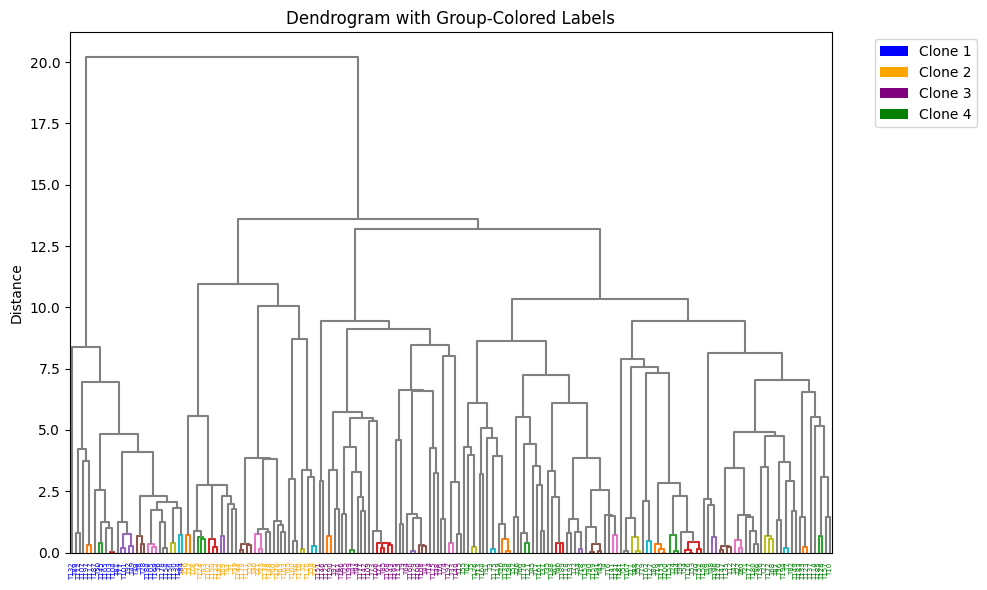

In [4]:
unique_groups = set(clone_ids)
color_list = ["blue","orange","purple","green"]
color_map = {group: color_list[i % len(color_list)] for i, group in enumerate(unique_groups)}
label_colors = [color_map[group] for group in clone_ids]

plt.figure(figsize=(10, 6))
dendro = dendrogram(linkage_matrix, labels=cell_ids, color_threshold=0.78, above_threshold_color="grey")
leaf_order = dendro["leaves"]
groupings_ordered = np.array(clone_ids)[leaf_order]

ax = plt.gca()
xlbls = ax.get_xmajorticklabels()
for lbl, group in zip(xlbls, groupings_ordered):
    lbl.set_color(color_map[group])

legend_elements = [Patch(facecolor=color_map[g], label=f'Clone {g}') for g in unique_groups]

plt.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1.2, 1))
plt.title('Dendrogram with Group-Colored Labels')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

# Compute the OU kernel

In [5]:
def tree_to_edge_list(tree):
    edge_list = []
    for edge in tree.edges():
        parent = edge.tail_node  # parent node
        child = edge.head_node  # child node
        
        if parent is None:
            continue

        branch_length = edge.length  # branch length
        
        parent_label = parent.label or (parent.taxon.label if parent.taxon else None) or str(id(parent))
        child_label = child.label or (child.taxon.label if child.taxon else None) or str(id(child))
        
        edge_list.append([parent_label, child_label, branch_length])
    
    return edge_list

edges = tree_to_edge_list(tree)

In [6]:
kernel = compute_ou_kernel(edges, list(assignments.keys()), lambd=0.5, sigma_squared=1.0)

assert kernel.shape[0] == kernel.shape[1]
assert kernel.shape[0] == N

# Simulate mu

Here we have 4 clones with phylogeny like this

```
    M
   / \
 C1   /\
     C2 /\
       C3 C4
```

Therefore, we need to simulate
- clonal mutations (shared)
- shared mutations between C2, C3, C4
- shared mutations between C3, C4
- private mutations

In [86]:
def alpha(phi, kappa):
    return phi * kappa

def beta(phi, kappa):
    return (1-phi) * kappa

def compute_mean_frequency(k_list):
    return len([c for c in clone_ids if c in k_list]) / len(clone_ids) / 2

def get_indexes(k_list):
    return [i for i,v in enumerate(clone_ids) if v in k_list]

def sample_beta(k_list, size_rows, N):
    idxs = get_indexes(k_list)
    samples = np.zeros((size_rows, N))
    samples[:, idxs] = logit(np.random.beta(alpha(compute_mean_frequency(k_list), kappa), beta(compute_mean_frequency(k_list), kappa), size=(size_rows, len(idxs))))
    return samples

mu = np.zeros((V, N))

idxs = [i for i in range(V)]
clonal_mutations = np.random.choice(idxs, size=int(V * 0.3), replace=False)  # 30% of muts will be clonal
[idxs.remove(_) for _ in clonal_mutations]

shared_234 = np.random.choice(idxs, size=int(V * 0.2), replace=False)  # 20% of muts will be clonal
[idxs.remove(_) for _ in shared_234]

shared_34 = np.random.choice(idxs, size=int(V * 0.1), replace=False)  # 10% of muts will be clonal
[idxs.remove(_) for _ in shared_34]

private_1 = np.random.choice(idxs, size=int(V * 0.1), replace=False)  # 10% of muts will be clonal
[idxs.remove(_) for _ in private_1]

private_2 = np.random.choice(idxs, size=int(V * 0.1), replace=False)  # 10% of muts will be clonal
[idxs.remove(_) for _ in private_2]

private_3 = np.random.choice(idxs, size=int(V * 0.1), replace=False)  # 10% of muts will be clonal
[idxs.remove(_) for _ in private_3]

private_4 = np.random.choice(idxs, size=int(V * 0.1), replace=False)  # 10% of muts will be clonal
[idxs.remove(_) for _ in private_4]

kappa = 200
mu[clonal_mutations,:] = np.random.beta(alpha(0.5, kappa), beta(0.5, kappa), size=(len(clonal_mutations), N))

mu[shared_234,:] = sample_beta([2,3,4], len(shared_234), N)
mu[shared_34,:] = sample_beta([3,4], len(shared_34), N)

mu[private_1,:] = sample_beta([1], len(private_1), N)
mu[private_2,:] = sample_beta([2], len(private_2), N)
mu[private_3,:] = sample_beta([3], len(private_3), N)
mu[private_4,:] = sample_beta([4], len(private_4), N)

# Simulate gamma and sample observed variables

In [93]:
gamma = np.zeros((V, N))
for v in range(V):
    gamma[v,:] = np.random.multivariate_normal(mu[v,:], kernel / 20)

theta = expit(gamma)
DP = np.full((V,N), 100) + np.round(np.random.normal(0, 1, size=(V,N))).astype(int)
AD = np.random.binomial(DP, theta)

In [94]:
frequencies = pd.DataFrame(theta)
frequencies.columns = cell_ids
frequencies["mutation_ids"] = frequencies.index
frequencies = pd.melt(frequencies, id_vars=["mutation_ids"], value_vars=cell_ids, var_name="cell_ids", value_name="VAF")

In [97]:
frequencies

,mutation_ids,cell_ids,theta
0,0,T186,0.630840
1,1,T186,0.473212
2,2,T186,0.510840
3,3,T186,0.420348
4,4,T186,0.519233
...,...,...,...
9995,45,T175,0.250324
9996,46,T175,0.312154
9997,47,T175,0.504762
9998,48,T175,0.401521


/orfeo/cephfs/scratch/cdslab/ebusca00/envs/virtualenv/snv_caller/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


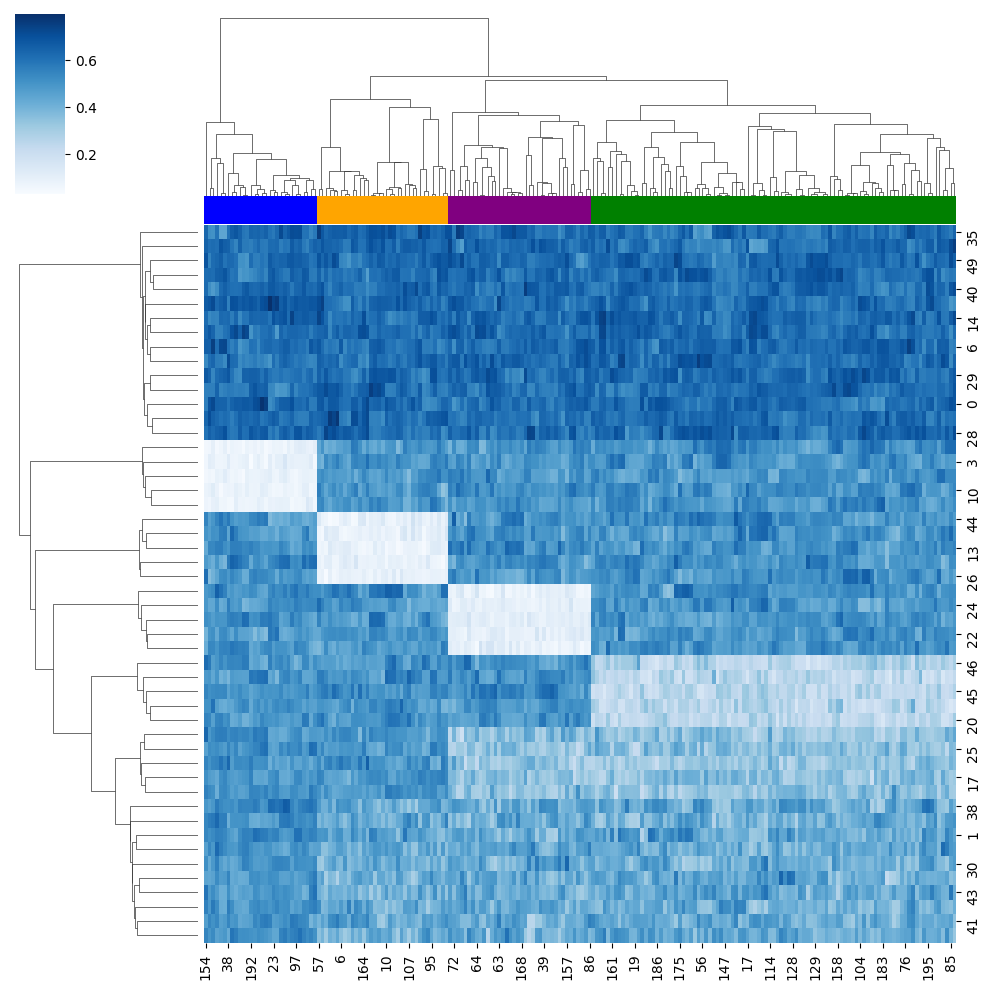

In [96]:
sns.clustermap(theta, col_colors=[color_map[i] for i in clone_ids], col_linkage=linkage_matrix, row_cluster=True, cmap="Blues")

# Other stuff

In [ ]:
# import ete3
# import numpy as np

# def simulate_tree(n_cells, branch_length_scale=1.0):
#     """Simulate a random binary tree with `n_cells` leaves."""
#     tree = ete3.Tree()
#     tree.populate(n_cells, random_branches=True)
    
#     # Optionally rescale branch lengths
#     for node in tree.traverse():
#         if not node.is_root():
#             node.dist *= branch_length_scale
    
#     return tree

# N = 10
# tree = simulate_tree(N)
# print(tree.get_ascii(show_internal=True))